# 1. Functions and parameters

Learn to define a reusable function with explicit inputs, validate its assumptions, return a result, and distinguish arguments from learned model parameters. You will implement and test a small error-measurement function. Prerequisite: [Conditions and loops](../../../01_Python_Foundations/05_conditions_and_loops.ipynb). Allow two hours, including tracing function calls and testing invalid inputs. No model training is required.

## 2. What problem does this solve?

Copying the same calculation into several notebook cells makes mistakes likely. One copy may use an old formula or a different denominator. A function names the operation and gives it a clear interface: what inputs it accepts, what result it returns, and how it responds when its assumptions are violated.

In ML experiments, consistent preprocessing and evaluation are essential. A reusable function helps consistency, but does not automatically guarantee a fair experiment. It can still read hidden global data, modify its inputs, or compute the wrong metric. We will make those risks visible rather than treating reuse as proof of correctness.

## 3. Intuition and analogy

Think of a function as a measuring instrument with labeled input sockets and an output display. The instrument should not secretly use an unrelated value left on a nearby desk. Supplying the same valid inputs to a deterministic, side-effect-free function should produce the same result.

The analogy also explains validation. A thermometer expects a temperature-related input process, not an arbitrary product code. Similarly, our metric expects paired numerical outcomes and predictions in the same units. Rejecting incompatible inputs protects the result's meaning.

## 4. Terminology

`def` introduces a **function definition**. A **parameter** is an input name in that definition; an **argument** is a value supplied when calling it. A **return value** is the result sent to the caller. A **local variable** belongs to a function call's scope. A **docstring** documents the function's purpose and assumptions.

A **default argument** is used when the caller omits that input. A **keyword argument** identifies a parameter by name. A **side effect** changes something outside the returned result, such as modifying an input list or writing a file. An **exception** signals a failed operation. A **pure function**, in the usual programming sense, produces its result from explicit inputs without observable side effects.

The word parameter has another meaning in ML: a learned coefficient. A Python function's parameter is not automatically a learned model parameter. Context determines the meaning.

## 5. Mathematical foundations

For actual outcomes $y_i$ and corresponding predictions $\hat y_i$, mean absolute error is

$$\mathrm{MAE}(y,\hat y)=\frac{1}{n}\sum_{i=1}^{n}|\hat y_i-y_i|,\qquad n>0.$$

n is the shared number of observations. Each outcome and prediction is a scalar; both collections have length n. Subtraction requires matching units. Absolute value removes the sign, and division by n calculates average magnitude. MAE retains the target's units, such as minutes.

The formula defines a mathematical function of two vectors. Our Python function implements that rule for small ordinary sequences, while adding explicit checks for a nonempty, paired, finite numerical domain.

## 6. Hand-calculated example

Actual travel times are `[3,5]` minutes and predictions are `[4,3]`. Residuals are $4-3=1$ and $3-5=-2$ minutes. Absolute errors are one and two. Their mean is $(1+2)/2=1.5$ minutes.

The signed mean residual is -0.5 minutes, a different measure describing average direction. Returning a value called `accuracy` for this regression calculation would obscure its meaning. Choose names that match the mathematical quantity and document its units at the application level.

## 7. Implementation from scratch

The first function calculates individual errors. The second combines them into a mean. This separation exposes intermediate values for debugging while avoiding duplication of input checks.

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
import math

def absolute_errors(actual, predicted):
    """Return paired absolute errors for nonempty finite Python numeric sequences."""
    if len(actual) != len(predicted):
        raise ValueError('Actual and predicted lengths must match')
    if len(actual) == 0:
        raise ValueError('At least one observation is required')
    errors = []
    for truth, guess in zip(actual, predicted):
        if type(truth) not in (int, float) or type(guess) not in (int, float):
            raise ValueError('Expected ordinary numeric values, excluding Boolean flags')
        if not math.isfinite(truth) or not math.isfinite(guess):
            raise ValueError('Values must be finite')
        errors.append(abs(guess - truth))
    return errors

def average_absolute_error(actual, predicted):
    """Return MAE without modifying either input sequence."""
    errors = absolute_errors(actual, predicted)
    return sum(errors) / len(errors)

actual = [3, 5]
predicted = [4, 3]
assert absolute_errors(actual, predicted) == [1, 2]
assert average_absolute_error(actual, predicted) == 1.5

## 8. Step-by-step output inspection

In [3]:
print('Individual errors:', absolute_errors(actual, predicted))
score = average_absolute_error(actual=actual, predicted=predicted)
print('MAE:', score, 'minutes')
assert actual == [3, 5] and predicted == [4, 3]

def error_report(actual, predicted, *, unit='minutes'):
    return {'mae': average_absolute_error(actual, predicted), 'unit': unit}

report = error_report(actual, predicted, unit='minutes')
assert report == {'mae': 1.5, 'unit': 'minutes'}
print('Returned report:', report)

Individual errors: [1, 2]
MAE: 1.5 minutes
Returned report: {'mae': 1.5, 'unit': 'minutes'}


Named arguments make the roles explicit. The `*` in `error_report` requires later parameters to be supplied by keyword, so the unit cannot accidentally be mistaken for a third data vector. `return` supplies a result; `print` only displays information. Printing a number without returning it leaves the caller with `None`.

## 9. Library implementation

In [4]:
from sklearn.metrics import mean_absolute_error as library_mae
library_score = library_mae(actual, predicted)
assert library_score == score
assert average_absolute_error(predicted, actual) == score
print('Library MAE:', library_score)

Library MAE: 1.5


MAE is symmetric, so swapping these two vectors produces the same numerical score. Other metrics are not necessarily symmetric; this is not a reason to ignore argument order generally. The library supports broader input types and options. Our function deliberately accepts a narrower domain to keep validation and mechanics inspectable.

## 10. Visualization

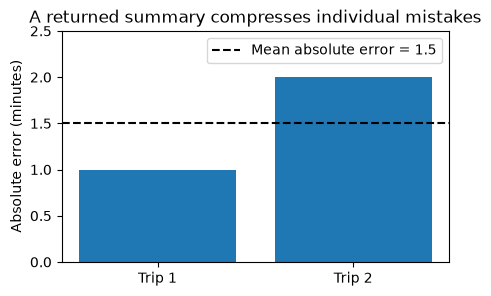

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
errors = absolute_errors(actual, predicted)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Trip 1', 'Trip 2'], errors)
ax.axhline(score, color='black', linestyle='--', label='Mean absolute error = 1.5')
ax.set(ylabel='Absolute error (minutes)', title='A returned summary compresses individual mistakes', ylim=(0, 2.5))
ax.legend()
display(fig)
plt.close(fig)

Neither trip's error equals 1.5 minutes. A mean summarizes the errors; it does not claim every example has that error. Keeping an individual-error function helps inspect failures that a single aggregate would hide.

## 11. Realistic experiment: invalid calls

A useful function fails clearly when its mathematical domain is violated. We deliberately test empty, mismatched, nonfinite, and Boolean inputs. The caught failures are expected tests, not hidden defects.

In [6]:
invalid_cases = [([], []), ([1], [1, 2]), ([1], [float('nan')]), ([True], [1])]
rejected = 0
for truth, guess in invalid_cases:
    try:
        average_absolute_error(truth, guess)
    except ValueError as error:
        rejected += 1
        print('Expected rejection:', error)
    else:
        raise AssertionError('An invalid call unexpectedly succeeded')
assert rejected == len(invalid_cases)
assert average_absolute_error([0], [0]) == 0

Expected rejection: At least one observation is required
Expected rejection: Actual and predicted lengths must match
Expected rejection: Values must be finite
Expected rejection: Expected ordinary numeric values, excluding Boolean flags


A real evaluation system additionally tracks observation identity and units. Equal lengths do not prove that outcomes are paired with the correct predictions. Function-level checks complement the broader experimental protocol rather than replacing it.

## 12. Inputs, defaults and configuration

Defaults are evaluated when a function is defined, so a mutable default list can be shared across calls. Use `None` when each omitted list should be created independently.

In [7]:
def record_value(value, history=None):
    if history is None:
        history = []
    history.append(value)
    return history

first = record_value(1)
second = record_value(2)
assert first == [1] and second == [2] and first is not second
explicit_history = []
record_value(3, explicit_history)
assert explicit_history == [3]

This function intentionally modifies an explicitly supplied history. Its contract should say so. For a side-effect-free alternative, copy the supplied sequence before appending. Neither choice is universally correct; clarity about the interface is the goal.

## 13. Evaluation

Test a hand-calculated case, perfect predictions, one observation, invalid inputs, and input preservation. Test invariants where appropriate: adding the same constant to actual and predicted values leaves MAE unchanged; multiplying both by a factor multiplies MAE by the factor's absolute value. Such properties cover more than one memorized example.

In [8]:
shifted_actual = [value + 10 for value in actual]
shifted_predicted = [value + 10 for value in predicted]
assert average_absolute_error(shifted_actual, shifted_predicted) == score
assert average_absolute_error([2 * value for value in actual], [2 * value for value in predicted]) == 2 * score

## 14. Assumptions and limitations

Our teaching function assumes ordinary Python numeric sequences and unweighted single-output examples. It intentionally rejects Boolean flags and does not support generators without lengths or every NumPy scalar type. It is not a production-equivalent replacement for the library. Very large magnitudes can also challenge floating-point arithmetic despite finite input checks.

## 15. Common mistakes and debugging

Do not omit `return` when the caller needs a value. Do not accidentally reference a global target list instead of the supplied argument. Do not mutate inputs while calculating a metric unless that behavior is explicitly required. Avoid mutable defaults that unintentionally retain prior calls. Read the exception and reproduce the smallest failing call before editing unrelated notebook cells.

## 16. Comparison with alternatives

An inline expression is adequate for a single obvious calculation. A function is useful for repeated work, testing, and naming a concept. A module collects related reusable functions; a class can manage state when state is genuinely part of the problem. Do not introduce a complex object hierarchy for a small stateless numerical rule.

## 17. Exercises

1. **Beginner:** Identify parameters and arguments in a definition `def double(x)` called as `double(4)`.
2. **Beginner:** Calculate the MAE for actual `[2,8]` and predictions `[3,5]` before calling the function.
3. **Beginner:** Explain how a function that only prints its score differs from one that returns it.
4. **Intermediate:** Give two checks beyond matching lengths that protect the meaning of an evaluation call.
5. **Intermediate:** Explain why a mutable default history can make independent notebook runs depend on call order.
6. **Challenge:** Implement nonnegative weighted MAE, rejecting mismatched, nonfinite, negative, or all-zero weights. Verify the unweighted case and a hand-calculated weighted example.

## 18. Detailed solutions

1. x is the parameter name in the definition; four is the supplied argument value.
2. Absolute errors one and three average to two in the target's units.
3. Printing displays a value but implicitly returns `None` unless another return is present. Returning allows composition, storage, and tests.
4. Check finiteness and valid numerical types; at the application level also check observation pairing and compatible units.
5. One default list object can survive across calls, so later results include earlier values. A fresh list created from `None` avoids unintended sharing.
6. For errors `[1,2]` and weights `[1,3]`, weighted MAE is $(1\times1+3\times2)/(1+3)=7/4=1.75$. Weights are relative importance values, not extra observations of outcomes.

In [9]:
def weighted_mae(actual, predicted, weights=None):
    errors = absolute_errors(actual, predicted)
    if weights is None:
        weights = [1.0] * len(errors)
    if len(weights) != len(errors):
        raise ValueError('Weights must match the observation count')
    for weight in weights:
        if type(weight) not in (int, float) or not math.isfinite(weight) or weight < 0:
            raise ValueError('Weights must be finite nonnegative numbers')
    denominator = math.fsum(weights)
    if denominator <= 0:
        raise ValueError('At least one weight must be positive')
    numerator = math.fsum(error * weight for error, weight in zip(errors, weights))
    return numerator / denominator

assert weighted_mae(actual, predicted) == score
assert weighted_mae(actual, predicted, [1, 3]) == 1.75
for bad_weights in ([0, 0], [-1, 2], [1], [1, float('inf')]):
    try:
        weighted_mae(actual, predicted, bad_weights)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid weights accepted')
print('Weighted MAE:', weighted_mae(actual, predicted, [1, 3]))

Weighted MAE: 1.75


## 19. Knowledge check

**Parameter versus argument?** A definition's input name versus a supplied value. **Does print return the displayed value?** No. **Why reject empty input?** The mean's denominator would be zero. **What is a side effect?** An observable change beyond the returned result. **Are function parameters learned coefficients?** Not automatically; those are different uses of the same word.

## 20. Interview preparation

**Why prefer explicit inputs?** They make dependencies inspectable and tests reproducible. **What makes a useful function contract?** Defined inputs, outputs, constraints, failures, and side effects. **Why use None for a default list?** To create fresh per-call state when the argument is omitted. **How test numerical code beyond one example?** Use boundary cases, independent calculations, and justified invariants. **When should a function become a module or class?** When reuse or state-management requirements justify the extra structure, rather than merely because code has grown longer.

## 21. Summary and next steps

Reusable calculations need explicit information flow, not just a function name. Next study [Scope](../../../01_Python_Foundations/07_scope.ipynb) to understand how Python resolves names and how hidden global state can affect notebooks. The [progress ledger](../../../PROGRESS.md) records what is available.